[*********************100%***********************]  1 of 1 completed


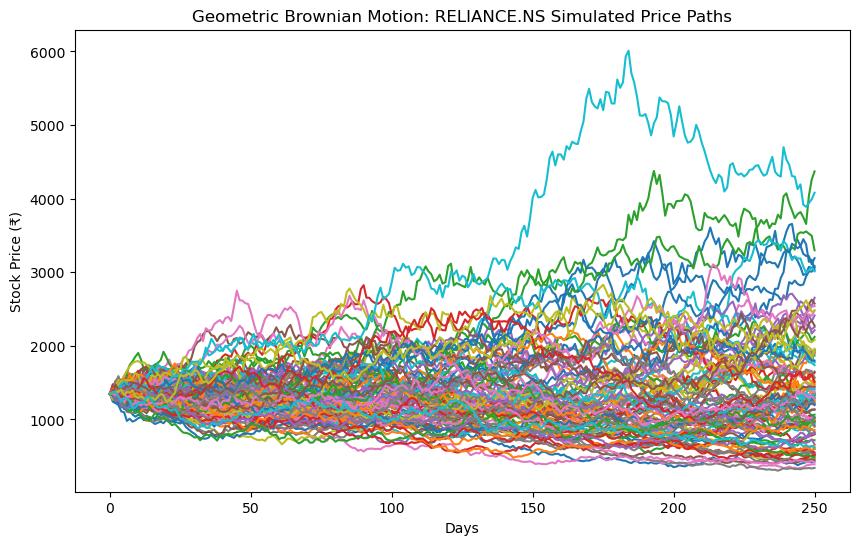

Call Option value under Euler Discretization method is ₹224.77 when Stock Price is ₹1349.60


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import yfinance as yf
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Sec_Data = yf.download("RELIANCE.NS",start='2000-1-1',end='2026-5-22',auto_adjust=False)['Adj Close']

Return = np.log(1 + Sec_Data.pct_change())
Std = Return.std()*np.sqrt(250)
Std = Std.values
Rf = 0.07
K = 1600

T = 1 #Duration in Years
Days = 250
Iteration = 100000 #Greater number to reduce and to get reliable result
Delta = T/Days #Intervalus per Duration

Z = np.random.standard_normal((Days+1,Iteration)) #It takes only one argument therefore inside the bracket mention no of rows and coloumns
S = np.zeros_like(Z)
S0 = Sec_Data.iloc[-1]
S[0] = S0

for t in range(1,Days+1):
    S[t] = S[t-1] * np.exp((Rf-0.5*Std**2)*Delta+Std*np.sqrt(Delta)*Z[t])

plt.figure(figsize=(10,6))
plt.plot(S[:, :100]) # Plotting the first 100 paths to keep it clean
plt.title("Geometric Brownian Motion: RELIANCE.NS Simulated Price Paths")
plt.xlabel("Days")
plt.ylabel("Stock Price (₹)")
plt.show()

p = np.maximum(S[-1]-K,0)

C = np.exp(-Rf*T)*np.sum(p)/Iteration

print(f"Call Option value under Euler Discretization method is ₹{C:.2f} when Stock Price is ₹{float(S0):.2f}")